# Clustering Methods in Scikit-Learn

In this exercise, three clustering algorithms from `sklearn` are applied to the Iris dataset:
K-Means, DBSCAN, and Agglomerative Hierarchical Clustering.
The class labels are withheld during clustering and used only for evaluation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage

os.makedirs('figures', exist_ok=True)
RANDOM_STATE = 42


## 1. Data Loading and Preprocessing

The Iris dataset is loaded from `sklearn.datasets`. Features are standardised with `StandardScaler` before clustering, and PCA is applied to obtain a 2D projection for visualisation.

In [2]:
iris = load_iris()
X = iris.data
y_true = iris.target          # used only for post-hoc evaluation
feature_names = iris.feature_names
target_names  = iris.target_names

# standardise so all features are on the same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# reduce to 2D for visualisation
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

df = pd.DataFrame(X, columns=feature_names)
df['species'] = [target_names[t] for t in y_true]
print(f'Dataset shape: {X.shape}')
df.head()

Dataset shape: (150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. Data Exploration

The PCA projection below shows the distribution of the three species in the first two principal components, which together explain 95.8% of the total variance.

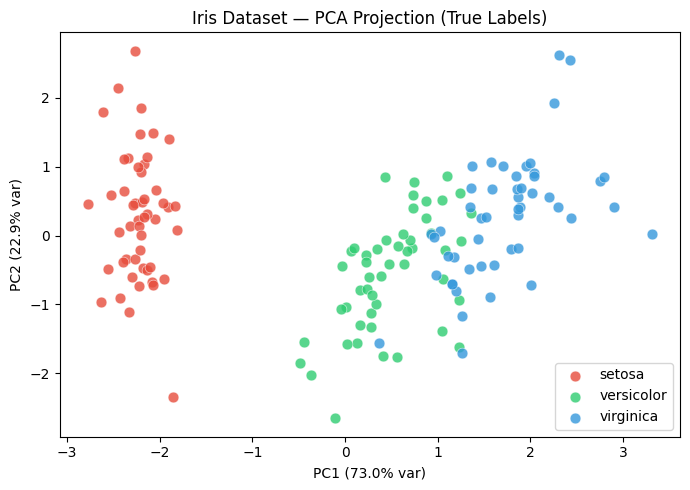

Explained variance ratio: [0.73  0.229]


In [3]:
fig, ax = plt.subplots(figsize=(7, 5))
palette = {'setosa': '#e74c3c', 'versicolor': '#2ecc71', 'virginica': '#3498db'}
for species, color in palette.items():
    mask = df['species'] == species
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=color, label=species, alpha=0.8, s=60, edgecolors='white', linewidths=0.4)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('Iris Dataset — PCA Projection (True Labels)')
ax.legend()
plt.tight_layout()
plt.savefig('figures/pca_true_labels.png', dpi=150)
plt.show()
print('Explained variance ratio:', pca.explained_variance_ratio_.round(3))

## 3. K-Means Clustering

K-Means partitions the data into *k* clusters by iteratively assigning points to the nearest centroid and recomputing centroids until convergence. The number of clusters must be specified in advance; the elbow method is used here to choose *k = 3*.

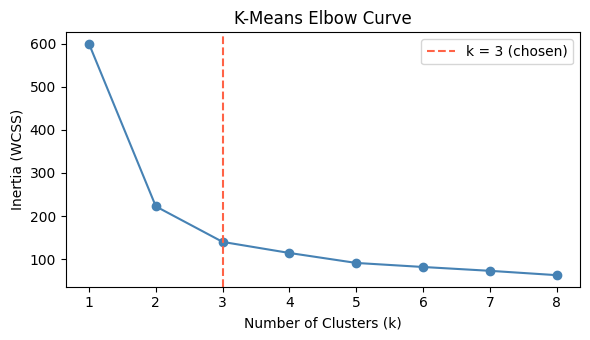

In [4]:
# elbow method
inertias = []
k_range = range(1, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(list(k_range), inertias, marker='o', color='steelblue')
ax.axvline(3, color='tomato', linestyle='--', label='k = 3 (chosen)')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (WCSS)')
ax.set_title('K-Means Elbow Curve')
ax.legend()
plt.tight_layout()
plt.savefig('figures/kmeans_elbow.png', dpi=150)
plt.show()

K-Means  |  Silhouette: 0.4599  |  ARI: 0.6201


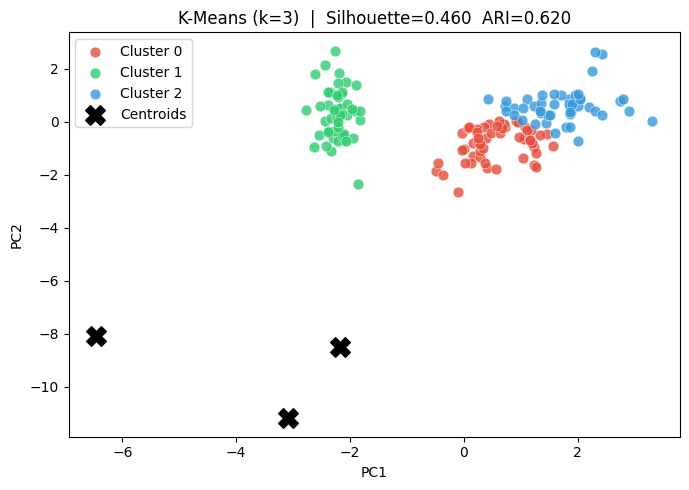

In [5]:
# fit with k=3
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
labels_km = kmeans.fit_predict(X_scaled)

sil_km  = silhouette_score(X_scaled, labels_km)
ari_km  = adjusted_rand_score(y_true, labels_km)
print(f'K-Means  |  Silhouette: {sil_km:.4f}  |  ARI: {ari_km:.4f}')

# project centroids into PCA space for plotting
centroids_pca = pca.transform(scaler.transform(kmeans.cluster_centers_))
colors_km = ['#e74c3c', '#2ecc71', '#3498db']

fig, ax = plt.subplots(figsize=(7, 5))
for lbl in range(3):
    mask = labels_km == lbl
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors_km[lbl], label=f'Cluster {lbl}', alpha=0.8, s=60,
               edgecolors='white', linewidths=0.4)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           marker='X', s=200, c='black', zorder=5, label='Centroids')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'K-Means (k=3)  |  Silhouette={sil_km:.3f}  ARI={ari_km:.3f}')
ax.legend()
plt.tight_layout()
plt.savefig('figures/kmeans_result.png', dpi=150)
plt.show()

## 4. DBSCAN

DBSCAN identifies clusters as dense regions separated by low-density areas. Points that do not belong to any dense region are labelled as noise (−1). The two key parameters are `eps` (neighbourhood radius) and `min_samples`. A k-NN distance plot is used to select an appropriate `eps`.

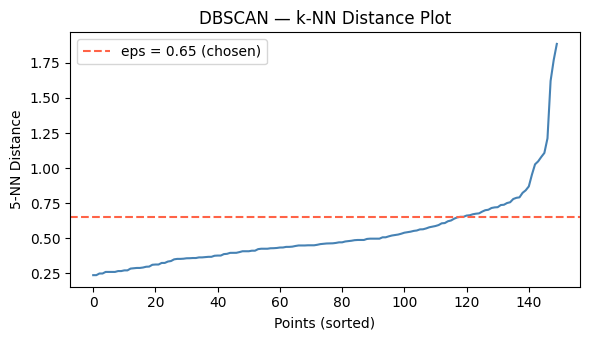

In [6]:
# k-NN distance plot to determine a suitable eps
from sklearn.neighbors import NearestNeighbors

nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, 4])   # 5th nearest neighbour distance

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(k_distances, color='steelblue')
ax.axhline(0.65, color='tomato', linestyle='--', label='eps = 0.65 (chosen)')
ax.set_xlabel('Points (sorted)')
ax.set_ylabel('5-NN Distance')
ax.set_title('DBSCAN — k-NN Distance Plot')
ax.legend()
plt.tight_layout()
plt.savefig('figures/dbscan_knn.png', dpi=150)
plt.show()

DBSCAN   |  Clusters: 2  |  Noise: 14  |  Silhouette: 0.4803  |  ARI: 0.4992


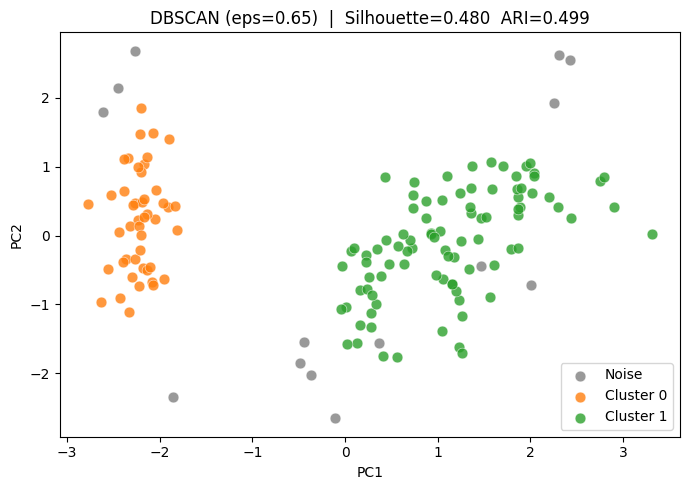

In [7]:
dbscan = DBSCAN(eps=0.65, min_samples=5)
labels_db = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db    = np.sum(labels_db == -1)
sil_db = silhouette_score(X_scaled, labels_db) if n_clusters_db > 1 else float('nan')
ari_db = adjusted_rand_score(y_true, labels_db)
print(f'DBSCAN   |  Clusters: {n_clusters_db}  |  Noise: {n_noise_db}  |  '
      f'Silhouette: {sil_db:.4f}  |  ARI: {ari_db:.4f}')

# noise points (label = -1) are shown in grey
unique_labels = sorted(set(labels_db))
cmap_db = plt.colormaps['tab10']
color_map = {lbl: ('grey' if lbl == -1 else cmap_db(i))
             for i, lbl in enumerate(unique_labels)}

fig, ax = plt.subplots(figsize=(7, 5))
for lbl in unique_labels:
    mask = labels_db == lbl
    label_str = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=[color_map[lbl]], label=label_str,
               alpha=0.8, s=60, edgecolors='white', linewidths=0.4)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'DBSCAN (eps=0.65)  |  Silhouette={sil_db:.3f}  ARI={ari_db:.3f}')
ax.legend()
plt.tight_layout()
plt.savefig('figures/dbscan_result.png', dpi=150)
plt.show()

## 5. Agglomerative Hierarchical Clustering

Agglomerative clustering takes a bottom-up approach: each sample starts as its own cluster, and pairs are merged iteratively based on a linkage criterion. Ward linkage is used here, which minimises the increase in total within-cluster variance at each merge step. The dendrogram is plotted to visually confirm that three clusters is a natural cut-off.

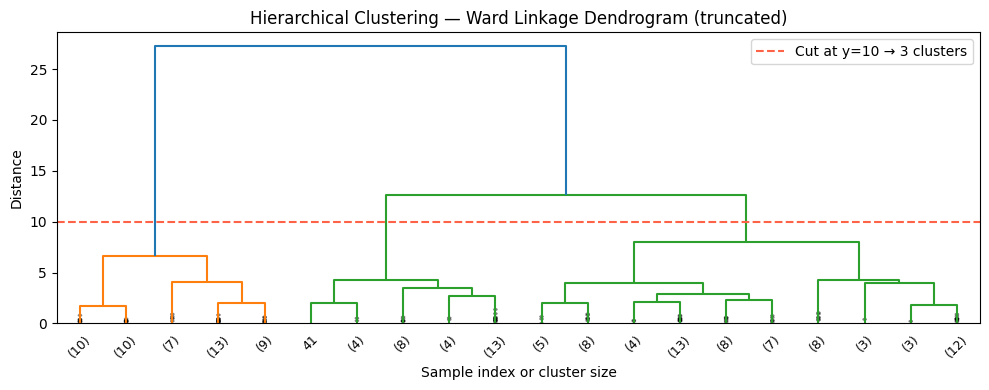

In [8]:
# truncated dendrogram
Z = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(10, 4))
dendrogram(Z, truncate_mode='lastp', p=20, leaf_rotation=45,
           leaf_font_size=9, show_contracted=True, ax=ax)
ax.axhline(y=10, color='tomato', linestyle='--', label='Cut at y=10 → 3 clusters')
ax.set_title('Hierarchical Clustering — Ward Linkage Dendrogram (truncated)')
ax.set_xlabel('Sample index or cluster size')
ax.set_ylabel('Distance')
ax.legend()
plt.tight_layout()
plt.savefig('figures/agg_dendrogram.png', dpi=150)
plt.show()

Agglom.  |  Silhouette: 0.4467  |  ARI: 0.6153


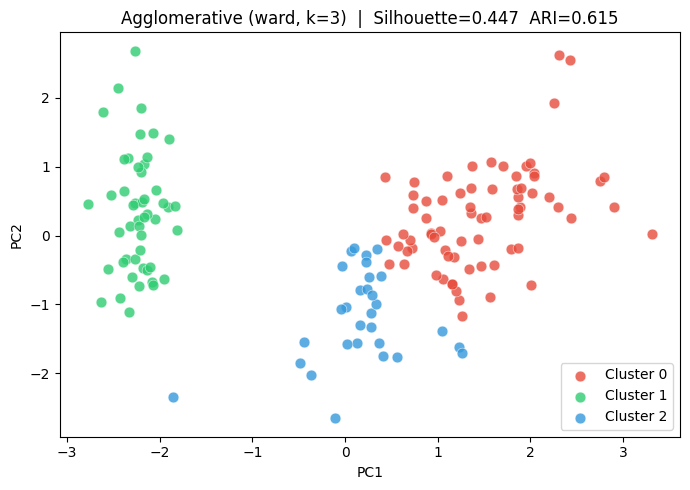

In [9]:
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_agg = agg.fit_predict(X_scaled)

sil_agg = silhouette_score(X_scaled, labels_agg)
ari_agg = adjusted_rand_score(y_true, labels_agg)
print(f'Agglom.  |  Silhouette: {sil_agg:.4f}  |  ARI: {ari_agg:.4f}')

colors_agg = ['#e74c3c', '#2ecc71', '#3498db']
fig, ax = plt.subplots(figsize=(7, 5))
for lbl in range(3):
    mask = labels_agg == lbl
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors_agg[lbl], label=f'Cluster {lbl}', alpha=0.8, s=60,
               edgecolors='white', linewidths=0.4)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title(f'Agglomerative (ward, k=3)  |  Silhouette={sil_agg:.3f}  ARI={ari_agg:.3f}')
ax.legend()
plt.tight_layout()
plt.savefig('figures/agg_result.png', dpi=150)
plt.show()

## 6. Results and Comparison

In [10]:
results = pd.DataFrame({
    'Method':      ['K-Means', 'DBSCAN', 'Agglomerative'],
    'Silhouette':  [round(sil_km, 4), round(sil_db, 4), round(sil_agg, 4)],
    'ARI':         [round(ari_km, 4), round(ari_db, 4), round(ari_agg, 4)],
    'Clusters Found': [len(np.unique(labels_km)),
                       len(set(labels_db)) - (1 if -1 in labels_db else 0),
                       len(np.unique(labels_agg))]
})
print(results.to_string(index=False))
results

       Method  Silhouette    ARI  Clusters Found
      K-Means      0.4599 0.6201               3
       DBSCAN      0.4803 0.4992               2
Agglomerative      0.4467 0.6153               3


,Method,Silhouette,ARI,Clusters Found
0,K-Means,0.4599,0.6201,3
1,DBSCAN,0.4803,0.4992,2
2,Agglomerative,0.4467,0.6153,3


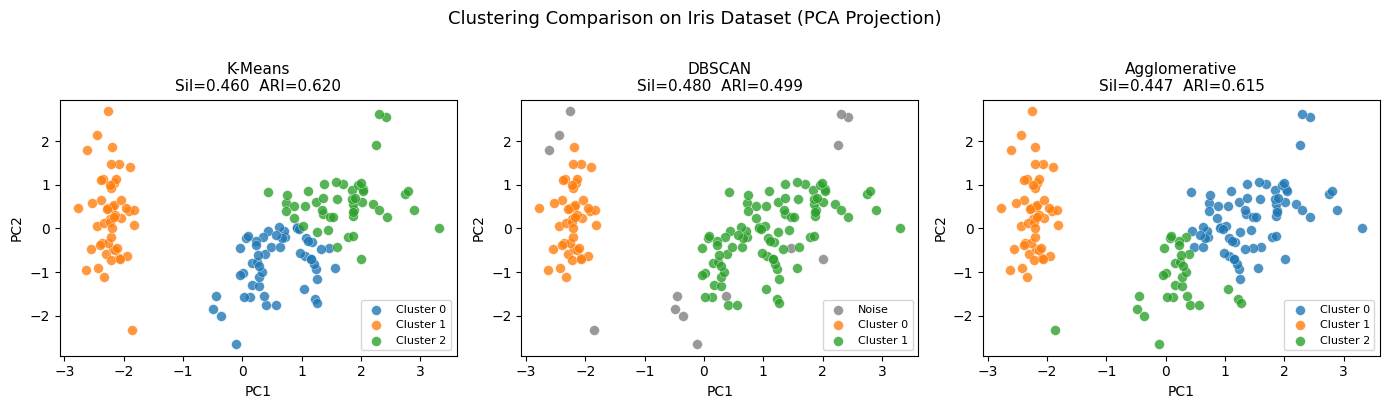

In [11]:
# side-by-side comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

configs = [
    ('K-Means',       labels_km,  sil_km,  ari_km),
    ('DBSCAN',        labels_db,  sil_db,  ari_db),
    ('Agglomerative', labels_agg, sil_agg, ari_agg),
]

cmap = plt.colormaps['tab10']
for ax, (title, labels, sil, ari) in zip(axes, configs):
    unique = sorted(set(labels))
    for i, lbl in enumerate(unique):
        mask = labels == lbl
        color = 'grey' if lbl == -1 else cmap(i % 10)
        lname = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   c=[color], label=lname, alpha=0.8, s=50,
                   edgecolors='white', linewidths=0.3)
    ax.set_title(f'{title}\nSil={sil:.3f}  ARI={ari:.3f}', fontsize=11)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=8)

plt.suptitle('Clustering Comparison on Iris Dataset (PCA Projection)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('figures/comparison.png', dpi=100, bbox_inches='tight')
plt.show()
